#### Generate Dataset

In [ ]:
import numpy as np
from scipy.signal import convolve2d
import os


GRID_SIZE = 20  # The dim of the board (GRID_SIZE x GRID_SIZE)
NUM_SAMPLES = 5000  # Total number of board pairs to generate
TRAIN_RATIO = 0.8  # 80% for training, 20% for validation
INITIAL_DENSITY = 0.3 # Probability of a cell being alive initially
OUTPUT_FILE = 'game_of_life_dataset.npz'

def game_of_life_step(grid):
    """
    Performs one step of Conway's Game of Life.
    Uses convolution to efficiently count neighbors.
    """
    kernel = np.array([[1, 1, 1],
                       [1, 0, 1],
                       [1, 1, 1]])
    neighbors = convolve2d(grid, kernel, mode='same', boundary='wrap')
    survives = (grid == 1) & ((neighbors == 2) | (neighbors == 3))
    births = (grid == 0) & (neighbors == 3)
    return (survives | births).astype(int)

def generate_gol_data(num_samples, grid_size, density):
    """
    Generates a dataset of Game of Life states.
    X: The board at time t
    y: The board at time t+1
    """
    X = np.zeros((num_samples, grid_size, grid_size, 1), dtype=np.uint8)
    y = np.zeros((num_samples, grid_size, grid_size, 1), dtype=np.uint8)

    print(f"Generating {num_samples} samples of {grid_size}x{grid_size} boards...")
    for i in range(num_samples):
        initial_state = np.random.choice([0, 1], size=(grid_size, grid_size), p=[1 - density, density])
        next_state = game_of_life_step(initial_state)
        X[i, :, :, 0] = initial_state
        y[i, :, :, 0] = next_state
        if (i + 1) % 500 == 0:
            print(f"  ... generated {i+1}/{num_samples}")
    return X, y

def main():
    """Main function to generate and save the dataset."""
    if os.path.exists(OUTPUT_FILE):
        print(f"Dataset '{OUTPUT_FILE}' already exists. Please delete it first to regenerate.")
        return

    X_data, y_data = generate_gol_data(NUM_SAMPLES, GRID_SIZE, INITIAL_DENSITY)

    indices = np.arange(NUM_SAMPLES)
    np.random.shuffle(indices)
    X_data, y_data = X_data[indices], y_data[indices]

    split_idx = int(NUM_SAMPLES * TRAIN_RATIO)
    X_train, X_val = X_data[:split_idx], X_data[split_idx:]
    y_train, y_val = y_data[:split_idx], y_data[split_idx:]

    # Create a dictionary of the arrays to save
    data_to_save = {
        'X_train': X_train,
        'y_train': y_train,
        'X_val': X_val,
        'y_val': y_val
    }

    # Save to a compressed npz file
    np.savez_compressed(OUTPUT_FILE, **data_to_save)

    print(f"\nDataset saved to '{OUTPUT_FILE}' with the following keys: {list(data_to_save.keys())}")
    print(f"Training set shape: {X_train.shape}")
    print(f"Validation set shape: {X_val.shape}")

if __name__ == '__main__':
    main()



Dataset 'game_of_life_dataset.npz' already exists. Please delete it first to regenerate.


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.optimizers import Adam
import random
import os
import matplotlib.pyplot as plt

DATASET_FILE = 'game_of_life_dataset.npz'
INPUT_SHAPE = (20, 20, 1)

# --- NAS (Evolutionary Algorithm) Configuration ---
POPULATION_SIZE = 10  # Number of architectures in each generation
NUM_GENERATIONS = 5   # How many generations to evolve
MUTATION_RATE = 0.5   # Probability of mutating an architecture
FITNESS_EPOCHS = 3    # Train for a few epochs to quickly evaluate fitness
TOURNAMENT_SIZE = 3   # Number of individuals to select for tournament selection

# --- Final Training Configuration ---
FINAL_TRAINING_EPOCHS = 30
BATCH_SIZE = 32

# --- Architecture Search Space ---
FILTER_OPTIONS = [4, 8, 16, 32]
KERNEL_SIZE_OPTIONS = [3, 5]
ACTIVATION_OPTIONS = ['relu', 'sigmoid', 'tanh', 'gaussian']
MAX_CONV_LAYERS = 4

# --- START Helper Functions for NAS ---

def create_random_architecture():
    """Creates a random architecture definition within the search space."""
    num_layers = random.randint(1, MAX_CONV_LAYERS)
    layers = []
    for _ in range(num_layers):
        layer_spec = {
            'filters': random.choice(FILTER_OPTIONS),
            'kernel_size': random.choice(KERNEL_SIZE_OPTIONS),
            'activation': random.choice(ACTIVATION_OPTIONS),
        }
        layers.append(layer_spec)
    return {'layers': layers}

def mutate_architecture(arch_def):
    """Applies random mutations to an architecture definition."""
    mutated_arch = {'layers': [l.copy() for l in arch_def['layers']]}

    if random.random() < MUTATION_RATE:
        mutation_type = random.choice(['change_filters', 'change_kernel', 'change_activation', 'add_layer', 'remove_layer'])

        if mutation_type == 'add_layer' and len(mutated_arch['layers']) < MAX_CONV_LAYERS:
            new_layer = {
                'filters': random.choice(FILTER_OPTIONS),
                'kernel_size': random.choice(KERNEL_SIZE_OPTIONS),
                'activation': random.choice(ACTIVATION_OPTIONS),
            }
            mutated_arch['layers'].insert(random.randint(0, len(mutated_arch['layers'])), new_layer)

        elif mutation_type == 'remove_layer' and len(mutated_arch['layers']) > 1:
            mutated_arch['layers'].pop(random.randint(0, len(mutated_arch['layers']) - 1))

        else:
            if not mutated_arch['layers']: return mutated_arch # Return if no layers to mutate
            layer_to_mutate = random.choice(mutated_arch['layers'])
            if mutation_type == 'change_filters':
                layer_to_mutate['filters'] = random.choice(FILTER_OPTIONS)
            elif mutation_type == 'change_kernel':
                layer_to_mutate['kernel_size'] = random.choice(KERNEL_SIZE_OPTIONS)
            elif mutation_type == 'change_activation':
                layer_to_mutate['activation'] = random.choice(ACTIVATION_OPTIONS)

    return mutated_arch

# --- ENDS Helper Functions for NAS ---

# --- Model Building and Training ---

def build_model(arch_def, input_shape):
    """Builds a Keras model from an architecture definition."""
    model = Sequential()

    tf_gaussian = lambda x: tf.exp(-x**2 / 2)
    for i, layer_spec in enumerate(arch_def['layers']):
        if i == 0:
            if layer_spec['activation'] == 'gaussian':
              model.add(Conv2D(
                  filters=layer_spec['filters'],
                  kernel_size=layer_spec['kernel_size'],
                  activation=tf_gaussian,
                  padding='same',
                  input_shape=input_shape
              ))
            else:
              model.add(Conv2D(
                  filters=layer_spec['filters'],
                  kernel_size=layer_spec['kernel_size'],
                  activation=layer_spec['activation'],
                  padding='same',
                  input_shape=input_shape
              ))
        else:
            if layer_spec['activation'] == 'gaussian':
              model.add(Conv2D(
                  filters=layer_spec['filters'],
                  kernel_size=layer_spec['kernel_size'],
                  activation=tf_gaussian,
                  padding='same'
              ))
            else:
              model.add(Conv2D(
                  filters=layer_spec['filters'],
                  kernel_size=layer_spec['kernel_size'],
                  activation=layer_spec['activation'],
                  padding='same'
              ))

    model.add(Conv2D(1, kernel_size=1, activation='sigmoid', padding='same'))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def evaluate_fitness(arch_def, X_train, y_train, X_val, y_val):
    """Evaluates the fitness of an architecture by training it for a few epochs."""
    try:
        model = build_model(arch_def, INPUT_SHAPE)
        history = model.fit(X_train, y_train, epochs=FITNESS_EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_val, y_val), verbose=0)
        # Use the final validation accuracy as the fitness score
        accuracy = history.history['val_accuracy'][-1]
        return accuracy
    except Exception as e:
        print(f"  [Warning] Invalid architecture encountered: {e}. Fitness set to 0.")
        return 0.0


In [ ]:


"""run the NAS experiment."""
# --- 1. Load Data ---
if not os.path.exists(DATASET_FILE):
    print(f"Error: Dataset file '{DATASET_FILE}' not found.")
    print("Please run 'game_of_life_generator.py' first.")


print("Loading dataset...")
with np.load(DATASET_FILE) as data:
    X_train, y_train = data['X_train'], data['y_train']
    X_val, y_val = data['X_val'], data['y_val']
print("Dataset loaded successfully.")

# --- 2. NAS ---
print("\n--- Starting Neural Architecture Search ---")

population = [create_random_architecture() for _ in range(POPULATION_SIZE)]

for gen in range(NUM_GENERATIONS):
    print(f"\nGeneration {gen + 1}/{NUM_GENERATIONS}")

    fitness_scores = [evaluate_fitness(arch, X_train, y_train, X_val, y_val) for arch in population]

    sorted_population = sorted(zip(population, fitness_scores), key=lambda x: x[1], reverse=True)
    population, fitness_scores = zip(*sorted_population)

    print(f"  Best Fitness (Validation Accuracy): {fitness_scores[0]:.4f}")
    print(f"  Best Architecture: {population[0]}")

    next_generation = []
    next_generation.append(population[0])

    while len(next_generation) < POPULATION_SIZE:
        tournament = random.sample(list(zip(population, fitness_scores)), TOURNAMENT_SIZE)
        winner = max(tournament, key=lambda x: x[1])[0]
        child = mutate_architecture(winner)
        next_generation.append(child)

    population = next_generation

best_arch_found = population[0]
print("\n--- NAS Finished ---")
print(f"Best architecture found: {best_arch_found}")

# --- 3. Final Model Comparison ---
print("\n--- Training Final Models for Comparison ---")

print("\n1. Training the Evolved Model...")
evolved_model = build_model(best_arch_found, INPUT_SHAPE)
history_evolved = evolved_model.fit(X_train, y_train, epochs=FINAL_TRAINING_EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_val, y_val), verbose=2)

print("\n2. Training the Fixed Baseline Model...")
fixed_arch = {
    'layers': [
        {'filters': 16, 'kernel_size': 3, 'activation': 'relu'},
        {'filters': 32, 'kernel_size': 3, 'activation': 'relu'}
    ]
}
print(f"Fixed baseline architecture: {fixed_arch}")
fixed_model = build_model(fixed_arch, INPUT_SHAPE)
history_fixed = fixed_model.fit(X_train, y_train, epochs=FINAL_TRAINING_EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_val, y_val), verbose=2)


Loading dataset...
Dataset loaded successfully.

--- Starting Neural Architecture Search ---

Generation 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Best Fitness (Validation Accuracy): 0.9461
  Best Architecture: {'layers': [{'filters': 16, 'kernel_size': 5, 'activation': 'sigmoid'}, {'filters': 32, 'kernel_size': 3, 'activation': 'tanh'}, {'filters': 8, 'kernel_size': 3, 'activation': 'gaussian'}, {'filters': 16, 'kernel_size': 5, 'activation': 'tanh'}]}

Generation 2/5
  Best Fitness (Validation Accuracy): 0.9474
  Best Architecture: {'layers': [{'filters': 8, 'kernel_size': 3, 'activation': 'tanh'}, {'filters': 32, 'kernel_size': 5, 'activation': 'relu'}, {'filters': 16, 'kernel_size': 5, 'activation': 'tanh'}]}

Generation 3/5
  Best Fitness (Validation Accuracy): 0.9473
  Best Architecture: {'layers': [{'filters': 8, 'kernel_size': 3, 'activation': 'tanh'}, {'filters': 32, 'kernel_size': 5, 'activation': 'relu'}, {'filters': 16, 'kernel_size': 5, 'activation': 'tanh'}]}

Generation 4/5
  Best Fitness (Validation Accuracy): 0.9471
  Best Architecture: {'layers': [{'filters': 8, 'kernel_size': 3, 'activation': 'tanh'}, {'filte


--- Final Evaluation ---
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9497 - loss: 0.0996


<>:43: SyntaxWarning: invalid escape sequence '\E'
<>:44: SyntaxWarning: invalid escape sequence '\F'
<>:43: SyntaxWarning: invalid escape sequence '\E'
<>:44: SyntaxWarning: invalid escape sequence '\F'
/tmp/ipython-input-948543132.py:43: SyntaxWarning: invalid escape sequence '\E'
  print(f"\Evolved model \n\ttrue_positives: {true_positives:.3f}, false_positives: {false_positives:.3f}, false negatives: {false_negatives:.3f}")
/tmp/ipython-input-948543132.py:44: SyntaxWarning: invalid escape sequence '\F'
  print(f"\Fixed model \n\ttrue_positives: {true_positives_fixed:.3f}, false_positives: {false_positives_fixed:.3f}, false negatives: {false_negatives_fixed:.3f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9492 - loss: 0.0996


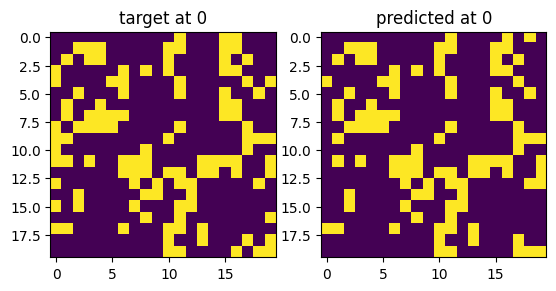

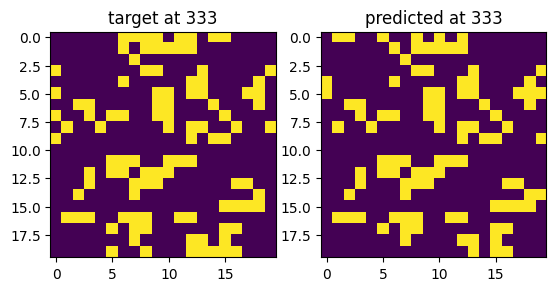

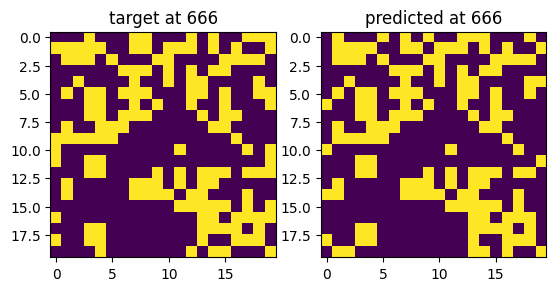

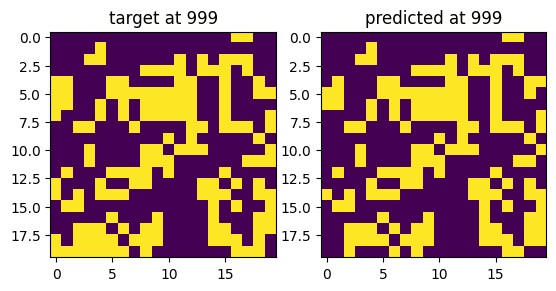


Evolved Model Final Accuracy: 94.95%
Fixed Baseline Model Final Accuracy: 94.91%
\Evolved model 
	true_positives: 0.892, false_positives: 0.020, false negatives: 0.038
\Fixed model 
	true_positives: 0.897, false_positives: 0.016, false negatives: 0.030

Conclusion:
The models performed similarly. This could mean the fixed architecture was already near-optimal,
or that the search space/algorithm needs more exploration to find a superior structure.


In [ ]:

# --- 4. Evaluate & Conclude ---
print("\n--- Final Evaluation ---")
_, evolved_acc = evolved_model.evaluate(X_val, y_val, verbose=1)
_, fixed_acc = fixed_model.evaluate(X_val, y_val, verbose=1)


# Evaluate performance on number of 'on' cells correct
decision_threshold = 0.5
y_val_predicted = 1.0 * (evolved_model(X_val).numpy() > decision_threshold)
y_val_fixed_predicted = 1.0 * (fixed_model(X_val).numpy() > decision_threshold)

# true positives, proportion of those on that are predicted to be on
correct_on = 1.0 * ((y_val_predicted * y_val)[y_val == 1] == y_val[y_val==1]).sum()
correct_on_fixed = 1.0 * ((y_val_fixed_predicted * y_val)[y_val == 1] == y_val[y_val==1]).sum()
total_on = y_val.sum()
true_positives = correct_on / total_on
true_positives_fixed = correct_on_fixed / total_on

# false positives, proportion of those off that are predicted to be on
incorrect_on = (y_val_predicted[y_val_predicted == 1] - y_val[y_val_predicted == 1]).sum()
incorrect_on_fixed = (y_val_fixed_predicted[y_val_predicted == 1] - y_val[y_val_predicted == 1]).sum()
total_off = (1 - y_val).sum()
false_positives = incorrect_on / total_off
false_positives_fixed = incorrect_on_fixed / total_off

# false negatives, proportion of on cells predicted to be off
incorrect_off = (y_val_predicted[y_val_predicted == 1] - y_val[y_val_predicted == 1]).sum()
incorrect_off_fixed = (y_val_fixed_predicted[y_val_predicted == 1] - y_val[y_val_predicted == 1]).sum()
false_negatives = incorrect_off / total_on

false_negatives_fixed = incorrect_off_fixed / total_on
#evolved_on_acc = 1.0 * ((y_val * (decision_threshold < y_val_predicted)) == y_val)

for target_index in range(0, y_val.shape[0], y_val.shape[0] // 3, ):
  plt.figure()
  plt.subplot(121); plt.imshow(y_val[target_index]); plt.title(f"target at {target_index}")
  plt.subplot(122); plt.imshow(y_val_predicted[target_index] > decision_threshold)
  plt.title(f"predicted at {target_index}")
plt.show()

print(f"\nEvolved Model Final Accuracy: {evolved_acc * 100:.2f}%")
print(f"Fixed Baseline Model Final Accuracy: {fixed_acc * 100:.2f}%")
print(f"\Evolved model \n\ttrue_positives: {true_positives:.3f}, false_positives: {false_positives:.3f}, false negatives: {false_negatives:.3f}")
print(f"\Fixed model \n\ttrue_positives: {true_positives_fixed:.3f}, false_positives: {false_positives_fixed:.3f}, false negatives: {false_negatives_fixed:.3f}")

print("\nConclusion:")
if evolved_acc > fixed_acc + 0.01:
    print("The model with the automatically discovered architecture performed significantly better.")
    print("This supports the hypothesis that allowing the model to learn its own structure can be more effective than using a fixed inductive bias.")
else:
    print("The models performed similarly. This could mean the fixed architecture was already near-optimal,")
    print("or that the search space/algorithm needs more exploration to find a superior structure.")

In [ ]:
import tensorflow
help(tensorflow.keras.layers.Conv2D)

Help on class Conv2D in module keras.src.layers.convolutional.conv2d:

class Conv2D(keras.src.layers.convolutional.base_conv.BaseConv)
 |  Conv2D(filters, kernel_size, strides=(1, 1), padding='valid', data_format=None, dilation_rate=(1, 1), groups=1, activation=None, use_bias=True, kernel_initializer='glorot_uniform', bias_initializer='zeros', kernel_regularizer=None, bias_regularizer=None, activity_regularizer=None, kernel_constraint=None, bias_constraint=None, **kwargs)
 |
 |  2D convolution layer.
 |
 |  This layer creates a convolution kernel that is convolved with the layer
 |  input over a 2D spatial (or temporal) dimension (height and width) to
 |  produce a tensor of outputs. If `use_bias` is True, a bias vector is created
 |  and added to the outputs. Finally, if `activation` is not `None`, it is
 |  applied to the outputs as well.
 |
 |  Note on numerical precision: While in general Keras operation execution
 |  results are identical across backends up to 1e-7 precision in fl

In [ ]:
for elem in dir(tensorflow):
  if "relu" in elem:
    print(elem)